In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import torch

from transformers import GPT2LMHeadModel, GPT2Tokenizer, logging

logging.set_verbosity_error()

In [24]:
model_name = 'gpt2'
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name)
#

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

# Tokenize text

In [25]:
text = "I wonder how many tokens are in pomegranate"
token_ids = tokenizer.encode(text, return_tensors='pt')
#
for i, t in enumerate(token_ids[0]):
  print(f' Token index {i:>2} is "{tokenizer.decode(t):7}"')

 Token index  0 is "I      "
 Token index  1 is " wonder"
 Token index  2 is " how   "
 Token index  3 is " many  "
 Token index  4 is " tokens"
 Token index  5 is " are   "
 Token index  6 is " in    "
 Token index  7 is " p     "
 Token index  8 is "ome    "
 Token index  9 is "gran   "
 Token index 10 is "ate    "


# Start and End index of a selected head

In [26]:
num_heads = model.config.n_head
num_embd = model.config.n_embd
head_size = num_embd // num_heads

selected_head = 2 # Index for third attention head

h3_start = head_size * selected_head
h3_end = h3_start + head_size

print(f'Head {selected_head} starts at {h3_start} and ends at {h3_end}')

Head 2 starts at 128 and ends at 192


# Replace the selected attention head with zeros

In [27]:
token_ids.shape

torch.Size([1, 11])

In [28]:
activations = {}
replaced_values = torch.zeros(head_size)

def implant_hook(layeri):
  def hook(module, input, output):
    q, k, v = output.chunk(3, dim=-1)
    k_copy = k.clone()
    k_copy[:, :, h3_start:h3_end] = replaced_values

    output = torch.cat((q, k_copy, v), dim=-1)
    activations[f'qkv_{layeri}'] = output.detach().numpy()

    return output
  return hook

#

layeri = 3
hh = model.transformer.h[layeri].attn.c_attn.register_forward_hook(implant_hook(layeri))

In [29]:
# Forward pass
with torch.no_grad(): model(token_ids)

In [30]:
# delete the hook handle
hh.remove()

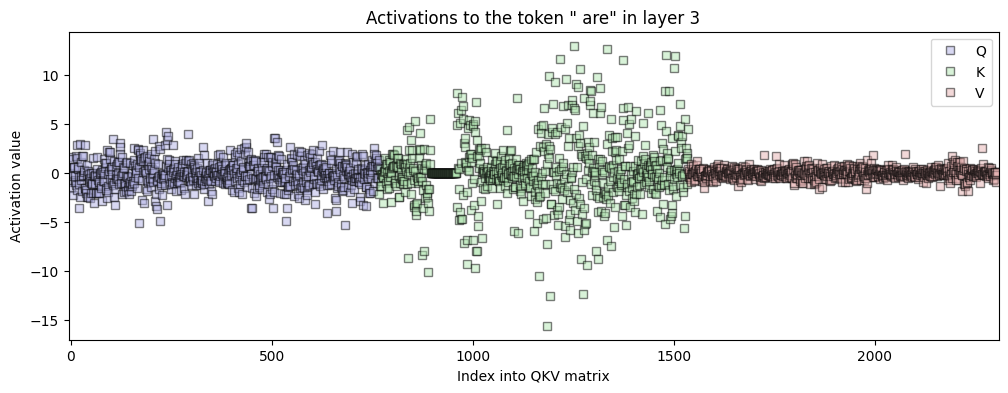

In [31]:
#Visualize
plt.figure(figsize=(12,4))
plt.plot(range(num_embd),activations[f'qkv_{layeri}'][0,5,:num_embd],'ks',markerfacecolor=[.7,.7,.9,.5],label='Q')
plt.plot(range(num_embd,2*num_embd),activations[f'qkv_{layeri}'][0,5,num_embd:num_embd*2],'ks',markerfacecolor=[.7,.9,.7,.5],label='K')
plt.plot(range(2*num_embd,3*num_embd),activations[f'qkv_{layeri}'][0,5,num_embd*2:],'ks',markerfacecolor=[.9,.7,.7,.5],label='V')

plt.legend()
plt.gca().set(xlim=[-5,num_embd*3+4],xlabel='Index into QKV matrix',ylabel='Activation value',
              title=f'Activations to the token "{tokenizer.decode(token_ids[0,5])}" in layer {layeri}')
plt.show()

# Replace the even-indexed MLP neurons with noise

In [32]:
# Initialize activations
activations = {}

def implant_hook(layeri):
  def hook(module, input, output):

    # Modify the even-indexed neurons from output for the 5th token with Gaussian noise
    output[:, 4, ::2] = torch.randn_like(output[:, 4, ::2]) + 10

    activations[f'mlp_{layeri}'] = output.detach().numpy()

    return output
  return hook

# Call the hook function for the 6th layer
layeri = 5

hh = model.transformer.h[layeri].mlp.c_fc.register_forward_hook(implant_hook(layeri))



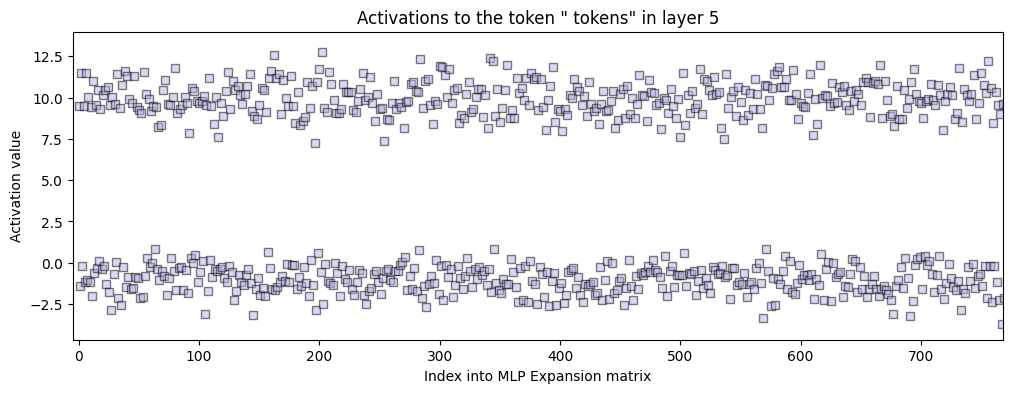

In [33]:
# Forward pass
with torch.no_grad(): model(token_ids)

# Visualize
plt.figure(figsize=(12,4))
plt.plot(activations[f'mlp_{layeri}'][0,4,:], 'ks', mfc=[.7,.7,.9,.5])
plt.gca().set(xlim=[-5,num_embd],xlabel='Index into MLP Expansion matrix',ylabel='Activation value',
              title=f'Activations to the token "{tokenizer.decode(token_ids[0,4])}" in layer 5')

plt.show()

In [34]:
# Delete the hook handle
hh.remove()

# Scale the hidden state activations

In [35]:
scaling_factor = .01

def implant_hook(module, input, output):

  # output is a tuple (hidden_states, present_key_value)
  # We want to scale the hidden_states (output[0])
  scaled_hidden_states = output[0] * scaling_factor

  # Return a new tuple with scaled hidden_states and the original present_key_value
  return (scaled_hidden_states, *output[1:])

hh = model.transformer.h[9].register_forward_hook(implant_hook)

In [36]:
out = model(token_ids, output_hidden_states=True)

hs = out.hidden_states
#
print(f'There are {len(hs)} hidden_states.')
print(f'Each hidden state is of size {list(hs[3].shape)}')


There are 13 hidden_states.
Each hidden state is of size [1, 11, 768]


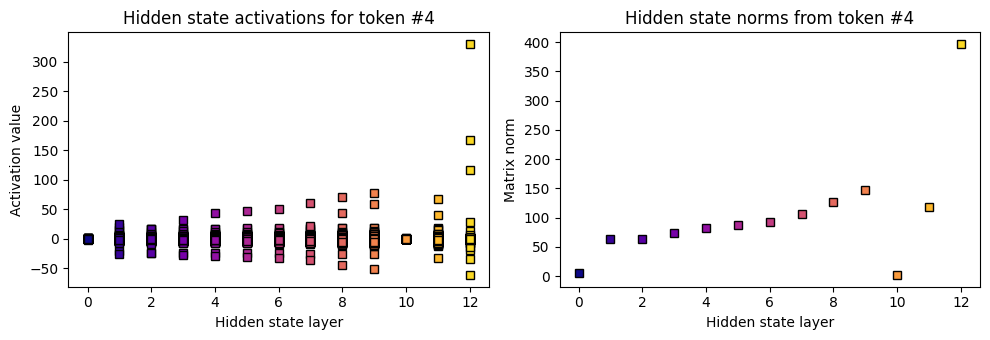

In [37]:
_,axs = plt.subplots(1,2,figsize=(10,3.5))

for i in range(len(hs)):

  # data from this transformer block for one token
  thisBlock = hs[i][0,4,:].detach().numpy()

  # plot all the data
  axs[0].plot(np.ones(num_embd)*i,thisBlock,'ks',markerfacecolor=mpl.cm.plasma(i/len(hs)))

  # plot the norm
  axs[1].plot(i,np.linalg.norm(thisBlock),'ks',markerfacecolor=mpl.cm.plasma(i/len(hs)))

axs[0].set(xlabel='Hidden state layer',ylabel='Activation value',title='Hidden state activations for token #4')
axs[1].set(xlabel='Hidden state layer',ylabel='Matrix norm',title='Hidden state norms from token #4')

plt.tight_layout()
plt.show()

In [41]:
scaling_factor = 10
out = model(token_ids,output_hidden_states=True)
hs = out.hidden_states

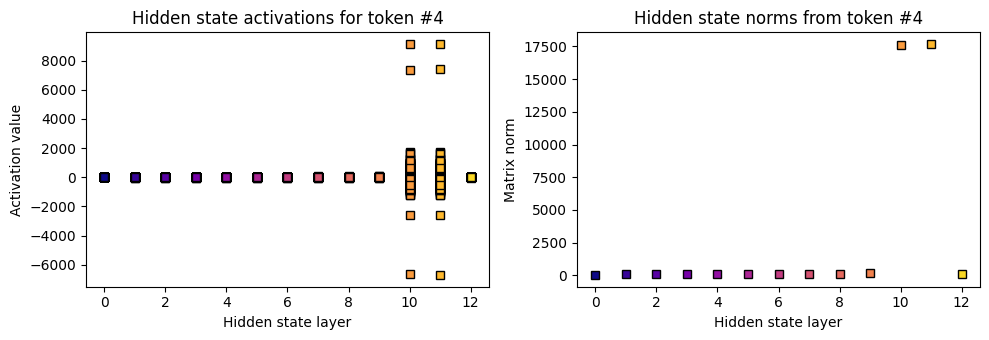

In [42]:
_,axs = plt.subplots(1,2,figsize=(10,3.5))

for i in range(len(hs)):

  # data from this transformer block for one token
  thisBlock = hs[i][0,4,:].detach().numpy()

  # plot all the data
  axs[0].plot(np.ones(num_embd)*i,thisBlock,'ks',markerfacecolor=mpl.cm.plasma(i/len(hs)))

  # plot the norm
  axs[1].plot(i,np.linalg.norm(thisBlock),'ks',markerfacecolor=mpl.cm.plasma(i/len(hs)))

axs[0].set(xlabel='Hidden state layer',ylabel='Activation value',title='Hidden state activations for token #4')
axs[1].set(xlabel='Hidden state layer',ylabel='Matrix norm',title='Hidden state norms from token #4')

plt.tight_layout()
plt.show()